In [1]:
import pandas as pd
import numpy as np
import os

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
data_files = {
    "orders": "orders.csv",
    "delivery_performance": "delivery_performance.csv",
    "customer_feedback": "customer_feedback.csv",
    "cost_breakdown": "cost_breakdown.csv",
    "routes_distance": "routes_distance.csv",
    "vehicle_fleet": "vehicle_fleet.csv",
    "warehouse_inventory": "warehouse_inventory.csv"
}

for name, path in data_files.items():
    df = pd.read_csv(path)
    print(f"\n {name.upper()} — Shape: {df.shape}")
    print(df.columns.tolist())



 ORDERS — Shape: (200, 9)
['Order_ID', 'Order_Date', 'Customer_Segment', 'Priority', 'Product_Category', 'Order_Value_INR', 'Origin', 'Destination', 'Special_Handling']

 DELIVERY_PERFORMANCE — Shape: (150, 8)
['Order_ID', 'Carrier', 'Promised_Delivery_Days', 'Actual_Delivery_Days', 'Delivery_Status', 'Quality_Issue', 'Customer_Rating', 'Delivery_Cost_INR']

 CUSTOMER_FEEDBACK — Shape: (83, 6)
['Order_ID', 'Feedback_Date', 'Rating', 'Feedback_Text', 'Would_Recommend', 'Issue_Category']

 COST_BREAKDOWN — Shape: (150, 8)
['Order_ID', 'Fuel_Cost', 'Labor_Cost', 'Vehicle_Maintenance', 'Insurance', 'Packaging_Cost', 'Technology_Platform_Fee', 'Other_Overhead']

 ROUTES_DISTANCE — Shape: (150, 7)
['Order_ID', 'Route', 'Distance_KM', 'Fuel_Consumption_L', 'Toll_Charges_INR', 'Traffic_Delay_Minutes', 'Weather_Impact']

 VEHICLE_FLEET — Shape: (50, 8)
['Vehicle_ID', 'Vehicle_Type', 'Capacity_KG', 'Fuel_Efficiency_KM_per_L', 'Current_Location', 'Status', 'Age_Years', 'CO2_Emissions_Kg_per_KM']

In [3]:
import pandas as pd

orders = pd.read_csv("orders.csv")
delivery = pd.read_csv("delivery_performance.csv")
feedback = pd.read_csv("customer_feedback.csv")
costs = pd.read_csv("cost_breakdown.csv")
routes = pd.read_csv("routes_distance.csv")

df = (orders
      .merge(delivery, on="Order_ID", how="left")
      .merge(feedback, on="Order_ID", how="left")
      .merge(costs, on="Order_ID", how="left")
      .merge(routes, on="Order_ID", how="left"))

print("Combined data shape:", df.shape)

Combined data shape: (200, 34)


In [4]:
df["is_return"] = df.apply(
    lambda x: 1 if (
        (str(x.get("Delivery_Status")).lower() == "returned") or
        (str(x.get("Quality_Issue")).lower() == "yes") or
        (str(x.get("Would_Recommend")).lower() == "no")
    ) else 0,
    axis=1
)

df["is_return"].value_counts()

,count
is_return,
0,178
1,22


In [5]:
df[["Order_ID", "Delivery_Status", "Quality_Issue", "Would_Recommend", "is_return"]].head(10)

,Order_ID,Delivery_Status,Quality_Issue,Would_Recommend,is_return
0,ORD000001,Slightly-Delayed,Perfect,NaN,0
1,ORD000002,Slightly-Delayed,Minor_Damage,Yes,0
2,ORD000003,Severely-Delayed,Minor_Damage,No,1
3,ORD000004,On-Time,Perfect,NaN,0
4,ORD000005,Slightly-Delayed,Perfect,NaN,0
5,ORD000006,Slightly-Delayed,Perfect,NaN,0
6,ORD000007,On-Time,Perfect,Yes,0
7,ORD000008,Severely-Delayed,Perfect,NaN,0
8,ORD000009,On-Time,Perfect,Yes,0
9,ORD000010,Severely-Delayed,Minor_Damage,NaN,0


In [6]:
df["is_return"].value_counts()

,count
is_return,
0,178
1,22


In [7]:
category_return = df.groupby("Product_Category")["is_return"].mean().sort_values(ascending=False)
print("Return rate by product category:\n", category_return)

priority_return = df.groupby("Priority")["is_return"].mean().sort_values(ascending=False)
print("\nReturn rate by order priority:\n", priority_return)

segment_return = df.groupby("Customer_Segment")["is_return"].mean().sort_values(ascending=False)
print("\nReturn rate by customer segment:\n", segment_return)

Return rate by product category:
 Product_Category
Electronics        0.137931
Fashion            0.117647
Industrial         0.111111
Food & Beverage    0.103448
Healthcare         0.100000
Home Goods         0.100000
Books              0.096774
Name: is_return, dtype: float64

Return rate by order priority:
 Priority
Economy     0.114286
Express     0.108696
Standard    0.107143
Name: is_return, dtype: float64

Return rate by customer segment:
 Customer_Segment
Individual    0.152542
SMB           0.111111
Enterprise    0.066667
Name: is_return, dtype: float64


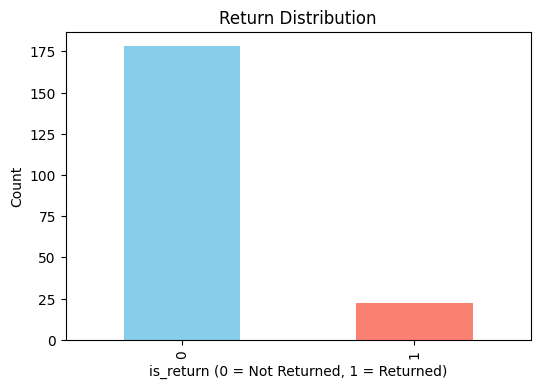

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df["is_return"].value_counts().plot(kind="bar", color=["skyblue", "salmon"])
plt.title("Return Distribution")
plt.xlabel("is_return (0 = Not Returned, 1 = Returned)")
plt.ylabel("Count")
plt.show()

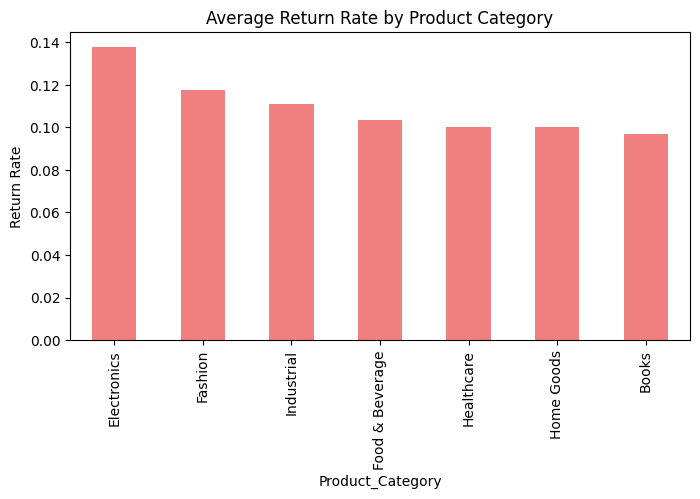

In [11]:
plt.figure(figsize=(8,4))
category_return.plot(kind="bar", color="lightcoral")
plt.title("Average Return Rate by Product Category")
plt.ylabel("Return Rate")
plt.show()

In [12]:
model_df = df[[
    "Order_Value_INR",
    "Priority",
    "Product_Category",
    "Customer_Segment",
    "Promised_Delivery_Days",
    "Actual_Delivery_Days",
    "Quality_Issue",
    "Would_Recommend",
    "Distance_KM",
    "is_return"
]].copy()

model_df.head()

,Order_Value_INR,Priority,Product_Category,Customer_Segment,Promised_Delivery_Days,Actual_Delivery_Days,Quality_Issue,Would_Recommend,Distance_KM,is_return
0,238.73,Express,Industrial,Individual,1.0,2.0,Perfect,NaN,152.59,0
1,17.01,Express,Industrial,SMB,2.0,3.0,Minor_Damage,Yes,362.05,0
2,3024.95,Economy,Industrial,SMB,10.0,15.0,Minor_Damage,No,519.74,1
3,56.74,Economy,Fashion,Individual,5.0,5.0,Perfect,NaN,540.87,0
4,19148.65,Standard,Fashion,SMB,4.0,5.0,Perfect,NaN,1251.56,0


In [13]:
model_df["Priority"].fillna("Standard", inplace=True)
model_df["Product_Category"].fillna("Unknown", inplace=True)
model_df["Customer_Segment"].fillna("Individual", inplace=True)
model_df["Quality_Issue"].fillna("No", inplace=True)
model_df["Would_Recommend"].fillna("Yes", inplace=True)
model_df["Promised_Delivery_Days"].fillna(model_df["Promised_Delivery_Days"].median(), inplace=True)
model_df["Actual_Delivery_Days"].fillna(model_df["Actual_Delivery_Days"].median(), inplace=True)
model_df["Distance_KM"].fillna(model_df["Distance_KM"].median(), inplace=True)

/tmp/ipython-input-574319038.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  model_df["Priority"].fillna("Standard", inplace=True)
/tmp/ipython-input-574319038.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in ["Priority", "Product_Category", "Customer_Segment", "Quality_Issue", "Would_Recommend"]:
    model_df[col] = le.fit_transform(model_df[col])

In [16]:
from sklearn.model_selection import train_test_split

X = model_df.drop("is_return", axis=1)
y = model_df["is_return"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 9)
Testing data: (40, 9)


In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1 Score:", round(f1_score(y_test, y_pred), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.975
Precision: 1.0
Recall: 0.75
F1 Score: 0.857

Confusion Matrix:
 [[36  0]
 [ 1  3]]


In [20]:
import joblib

joblib.dump(model, "model.pkl")
print("Model saved as model.pkl")

Model saved as model.pkl


In [26]:
#Using Random forest also
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))
print("Precision:", round(precision_score(y_test, y_pred_rf), 3))
print("Recall:", round(recall_score(y_test, y_pred_rf), 3))
print("F1 Score:", round(f1_score(y_test, y_pred_rf), 3))

Random Forest Results:
Accuracy: 0.9
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf)
    ]
})

print(results)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression     0.975        1.0    0.75  0.857143
1        Random Forest     0.900        0.0    0.00  0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [28]:
#Since random forest shows unrealistic results. I would resolve the overfitting by handling the columnns who are leaking the data which is causing overfitting.
leak_cols = ["Quality_Issue", "Would_Recommend", "Delivery_Status"]
X = df.drop(columns=leak_cols + ["is_return"], errors='ignore')
y = df["is_return"]

X = X.select_dtypes(include=["number"])

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))
print("Precision:", round(precision_score(y_test, y_pred_rf), 3))
print("Recall:", round(recall_score(y_test, y_pred_rf), 3))
print("F1 Score:", round(f1_score(y_test, y_pred_rf), 3))

Accuracy: 0.9
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [30]:
#I fix the imbalanced results
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight='balanced'   # 🔥 fixes imbalance
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Classification Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95        36
           1       0.00      0.00      0.00         4

    accuracy                           0.90        40
   macro avg       0.45      0.50      0.47        40
weighted avg       0.81      0.90      0.85        40


Confusion Matrix:
 [[36  0]
 [ 4  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [31]:
joblib.dump(rf_model, "rf_model.pkl")
print("Random Forest model saved as rf_model.pkl")

Random Forest model saved as rf_model.pkl


In [32]:
import os
os.listdir('/content')

['.config',
 'routes_distance.csv',
 'vehicle_fleet.csv',
 'rf_model.pkl',
 'orders.csv',
 'customer_feedback.csv',
 'warehouse_inventory.csv',
 'model.pkl',
 'cost_breakdown.csv',
 'delivery_performance.csv',
 'sample_data']

In [34]:
from google.colab import files
files.download('rf_model.pkl')
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
#Streamlit app
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt

st.set_page_config(page_title="Predictive Return Management System", page_icon="📦", layout="wide")

st.title("📦 Predictive Return Management System")
st.markdown("This app predicts the likelihood of a product return based on order and delivery details.")

@st.cache_resource
def load_model():
    model = joblib.load("rf_model.pkl")
    return model

model = load_model()

st.sidebar.header("Upload Order Data")
uploaded_file = st.sidebar.file_uploader("Upload your order CSV file", type=["csv"])

if uploaded_file is not None:
    data = pd.read_csv(uploaded_file)
    st.write("### Uploaded Data Preview")
    st.dataframe(data.head())

    required_features = ["Order_Value_INR", "Priority", "Product_Category",
                         "Customer_Segment", "Promised_Delivery_Days",
                         "Actual_Delivery_Days", "Distance_KM"]
    missing = [col for col in required_features if col not in data.columns]
    if missing:
        st.error(f"Missing columns: {missing}")
    else:
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        for col in ["Priority", "Product_Category", "Customer_Segment"]:
            data[col] = le.fit_transform(data[col].astype(str))

        predictions = model.predict(data[required_features])
        data["Return_Risk"] = ["Likely Return" if p == 1 else "No Return" for p in predictions]

        st.success("✅ Predictions complete!")
        st.write("### Prediction Results")
        st.dataframe(data[["Order_Value_INR", "Priority", "Product_Category", "Return_Risk"]])

        st.write("### Return Risk Distribution")
        fig, ax = plt.subplots()
        data["Return_Risk"].value_counts().plot(kind="bar", color=["skyblue", "salmon"], ax=ax)
        plt.xticks(rotation=0)
        st.pyplot(fig)

        csv = data.to_csv(index=False).encode("utf-8")
        st.download_button("⬇️ Download Results CSV", data=csv, file_name="predicted_returns.csv", mime="text/csv")

else:
    st.info("👈 Upload a CSV file from the sidebar to begin.")


Writing app.py


In [38]:
!ls /content

app.py			  model.pkl	       sample_data
cost_breakdown.csv	  orders.csv	       vehicle_fleet.csv
customer_feedback.csv	  rf_model.pkl	       warehouse_inventory.csv
delivery_performance.csv  routes_distance.csv


In [39]:
from google.colab import files
files.download('app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>